In [1]:
from pathlib import Path

import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

dataset = "bastidas-ponce_4K_pancreas-d15_rnaseq"
scarf.fetch_dataset(
    dataset_name=dataset,
    save_path="scarf_datasets",
    as_zarr=True,
)
ds = scarf.DataStore(
    str(Path("scarf_datasets") / dataset / "data.zarr"),
    nthreads=4,
    default_assay="RNA",
)

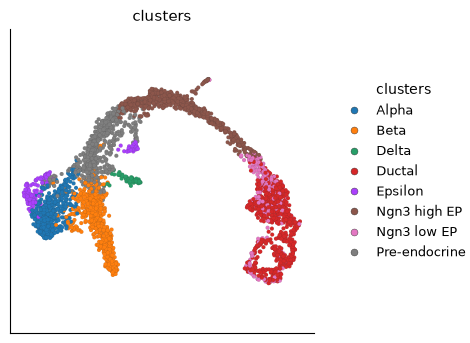

In [2]:
splt.embedding(ds, layout_key="RNA_UMAP", color_by="clusters");

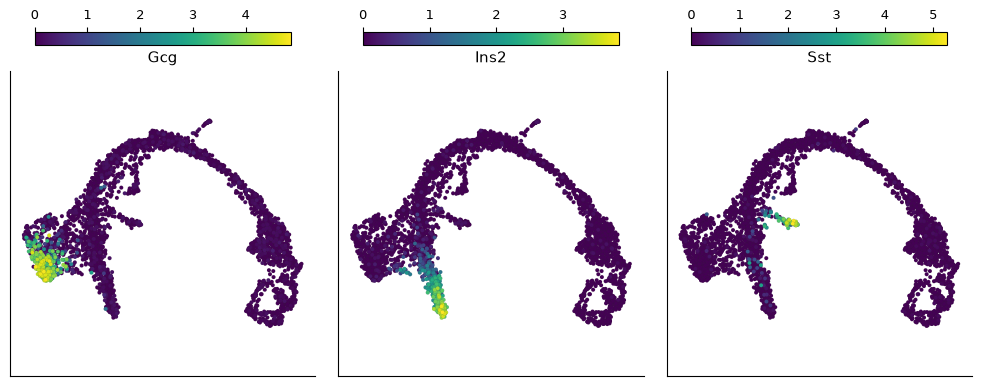

In [3]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by=["Gcg", "Ins2", "Sst"],
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
);

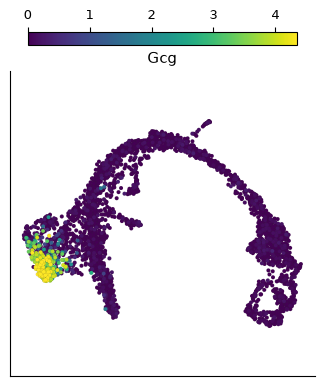

In [4]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="Gcg",
    normalization=splt.NormalizationSpec(transform="log1p"),
    color_scale=splt.ColorScale(cmap="viridis", quantiles=(0.0, 0.99)),
    sort_values=True,
);

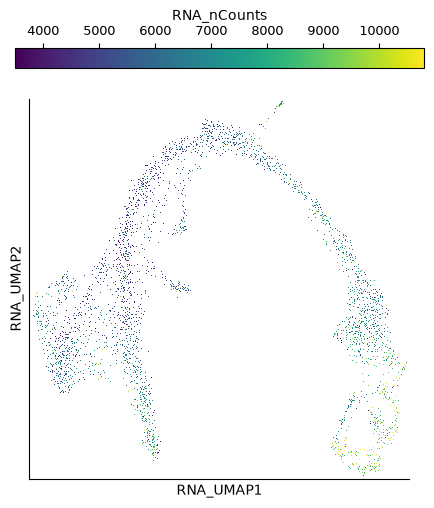

In [5]:
splt.embedding_raster(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_nCounts",
    pixels=400,
);

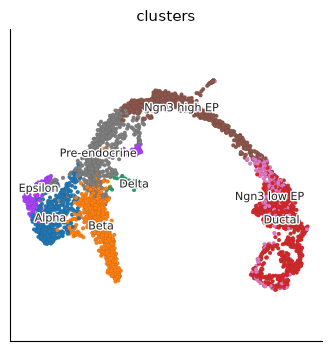

In [6]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="clusters",
    legend_loc="on_data",
);

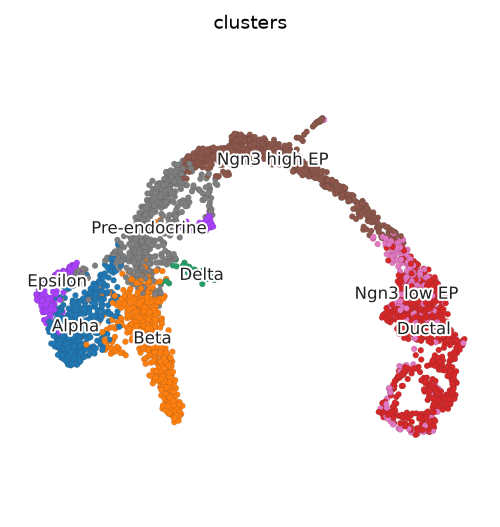

In [7]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="clusters",
    legend_loc="on_data",
    frame="none",
    theme="paper",
);

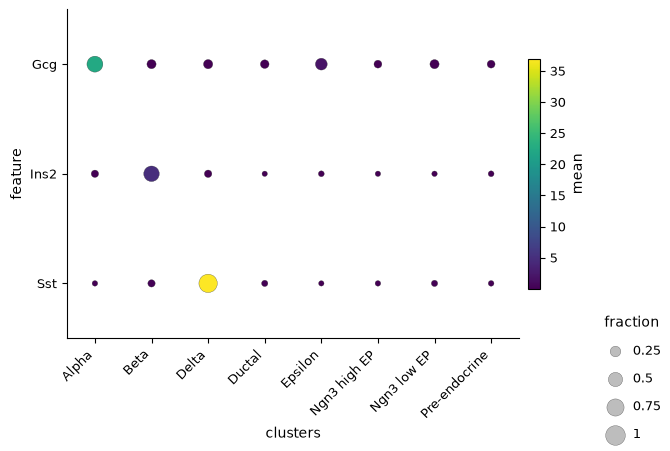

In [8]:
n = len(ds.cells.active_index("I"))
ds.cells.insert(
    "demo_sample",
    [f"s{i % 8}" for i in range(n)],
    overwrite=True,
)

splt.dotplot(
    ds,
    features={"endocrine": ["Gcg", "Ins2", "Sst"]},
    group_by="clusters",
    sample_by="demo_sample",
);

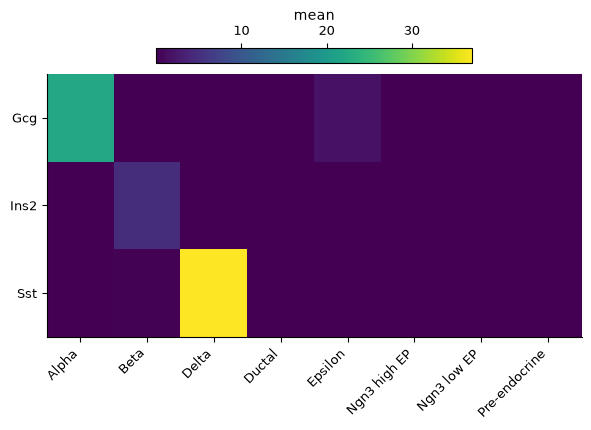

In [9]:
splt.matrixplot(
    ds,
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
    value="mean",
);

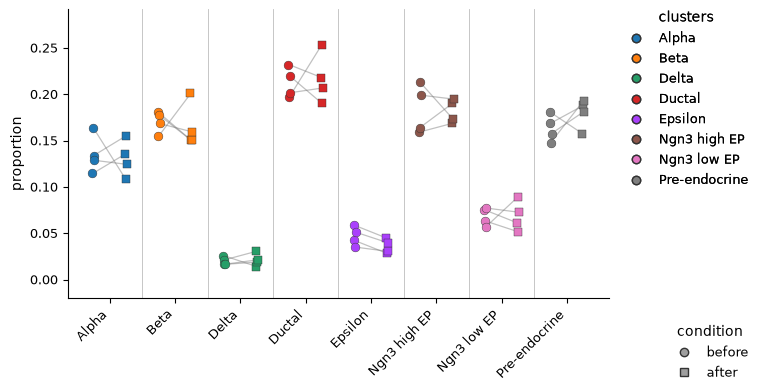

In [10]:
ds.cells.insert(
    "demo_subject",
    [f"d{i % 4}" for i in range(n)],
    overwrite=True,
)
ds.cells.insert(
    "demo_condition",
    ["before" if i % 8 < 4 else "after" for i in range(n)],
    overwrite=True,
)

splt.composition(
    ds,
    category_by="clusters",
    study_design=splt.StudyDesign(
        sample_by="demo_sample",
        subject_by="demo_subject",
        condition_by="demo_condition",
    ),
    kind="per_sample",
);

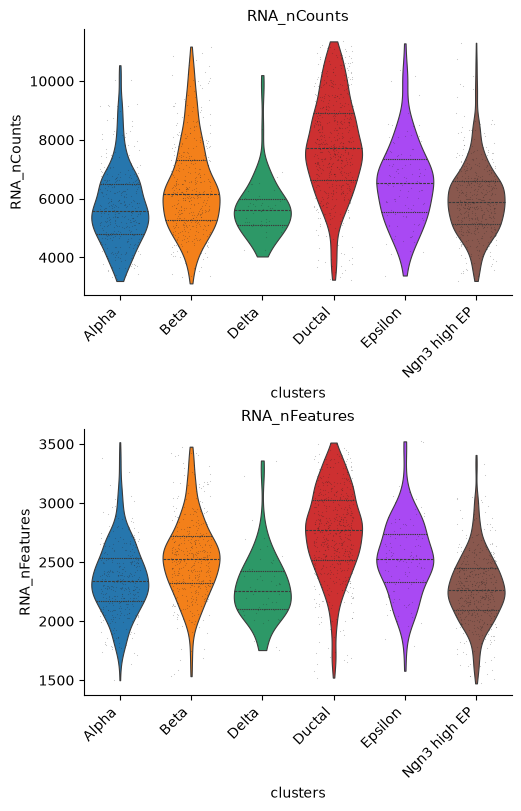

In [11]:
cluster_ids = sorted(set(ds.cells.fetch("clusters")), key=str)[:6]
splt.distribution(
    ds,
    keys=["RNA_nCounts", "RNA_nFeatures"],
    group_by="clusters",
    groups=cluster_ids,
    kind="violin",
    max_points=2000,
    seed=0,
);

In [12]:
from pathlib import Path

out = Path("scarf_datasets") / "plotting_showcase_embedding.png"
out.parent.mkdir(parents=True, exist_ok=True)
result = splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="clusters",
    show=False,
)
result.save(out, dpi=200)
assert out.exists()
result.close()